# Yelp sentiment - preserved full-run results

Srinidhi, Lab Pair 49. This notebook displays preserved training and evaluation results. Its inference cell reloads the selected checkpoints on CPU when executed. Generating this notebook does not execute its cells. The accompanying sentiment.py contains the complete model and training implementation; these presentation and inference cells do not retrain the models.

In [1]:
from pathlib import Path
import json
import pandas as pd
import torch
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file())
MEMBER = ROOT / "task2_sentiment/srinidhi"
OUTPUTS = MEMBER / "outputs/full"
summary = json.loads((OUTPUTS / "summary.json").read_text())
provenance = json.loads((OUTPUTS / "run_summary.json").read_text())
assert provenance["status"] == "completed" and summary["mode"] == "full"
print("Evaluation provenance")
display(provenance.get("evaluation_environment", provenance.get("environment", {})))
sources = json.loads((OUTPUTS / "training_sources.json").read_text())
for name, source in sources.items():
    print(name, "training source:", source["source_run"])
    display(source["hardware"])
    display(json.loads((OUTPUTS / name / "training_config.json").read_text()))
selection_path = OUTPUTS / "selection_manifest.json"
if selection_path.is_file():
    selection = json.loads(selection_path.read_text())
    print("Selection rule:", selection["selection_rule"])
    selected_models = [{"model": name, "source_run": source["source_run"],
                        "selected_epoch": source["selected_epoch"],
                        "validation_macro_f1": source["validation_macro_f1"],
                        "checkpoint_sha256": source["sha256"]}
                       for name, source in selection["selected"].items()]
    display(pd.DataFrame(selected_models))
display(json.loads((OUTPUTS / "data_audit.json").read_text()))

Evaluation provenance


{'captured_utc': '2026-09-19T02:44:27.599322+00:00',
 'python': '3.12.14',
 'platform': 'macOS-27.0-arm64-arm-64bit',
 'machine': 'arm64',
 'packages': {'torch': '2.11.0',
  'torchvision': '0.26.0',
  'numpy': '2.5.3',
  'pandas': '3.0.6',
  'scikit-learn': '1.9.1',
  'scipy': '1.16.3',
  'matplotlib': '3.11.2',
  'datasets': '5.0.1',
  'Pillow': '12.3.0',
  'clean-fid': '0.1.35',
  'lpips': '0.1.4',
  'prdc': '0.2'},
 'cuda_available': False,
 'cuda_build': None,
 'cudnn': None,
 'gpus': [],
 'mps_available': True}

maxpool_mlp training source: runs/part-b-full


{'cpu': 'AMD EPYC 7543 32-Core Processor',
 'cpu_source': 'verification/part_b_cpu_hardware.txt',
 'gpu': 'NVIDIA GeForce RTX 5090'}

{'mode': 'full',
 'seed': 2342,
 'dataset': 'fancyzhx/yelp_polarity',
 'dataset_revision': 'main',
 'data_dir': 'task2_sentiment/srinidhi/data_processed/full',
 'train_limit': None,
 'validation_limit': None,
 'test_limit': None,
 'vocabulary_size': 40000,
 'min_frequency': 2,
 'embedding_dim': 128,
 'max_length': 384,
 'batch_size': 128,
 'epochs': 6,
 'early_stopping_patience': 2,
 'early_stopping_min_delta': 0.0001,
 'mlp_hidden': 64,
 'lstm_hidden': 96,
 'cnn_channels': 128,
 'dilations': [1, 2, 4, 8],
 'dropout': 0.3,
 'cnn_dropout': 0.2,
 'learning_rates': {'maxpool_mlp': 0.0015,
  'bilstm': 0.001,
  'dilated_cnn': 0.0008},
 'weight_decay': 0.0001,
 'gradient_clip': 1.0,
 'amp': True,
 'bootstrap_samples': 1000,
 'cpu_threads': 2,
 'raw_data_cache': 'task2_sentiment/data/huggingface',
 'encoded_cache': 'task2_sentiment/srinidhi/data_processed/full_encoded',
 'num_workers': 2,
 'log_every_steps': 50}

...

{'cpu': 'AMD EPYC 7543 32-Core Processor',
 'cpu_source': 'verification/part_b_cpu_hardware.txt',
 'gpu': 'NVIDIA GeForce RTX 5090'}

{'mode': 'full',
 'seed': 2342,
 'dataset': 'fancyzhx/yelp_polarity',
 'dataset_revision': 'main',
 'data_dir': 'task2_sentiment/srinidhi/data_processed/full',
 'train_limit': None,
 'validation_limit': None,
 'test_limit': None,
 'vocabulary_size': 40000,
 'min_frequency': 2,
 'embedding_dim': 128,
 'max_length': 384,
 'batch_size': 128,
 'epochs': 6,
 'early_stopping_patience': 2,
 'early_stopping_min_delta': 0.0001,
 'mlp_hidden': 64,
 'lstm_hidden': 96,
 'cnn_channels': 128,
 'dilations': [1, 2, 4, 8],
 'dropout': 0.3,
 'cnn_dropout': 0.2,
 'learning_rates': {'maxpool_mlp': 0.0015,
  'bilstm': 0.001,
  'dilated_cnn': 0.0008},
 'weight_decay': 0.0001,
 'gradient_clip': 1.0,
 'amp': True,
 'bootstrap_samples': 1000,
 'cpu_threads': 2,
 'raw_data_cache': 'task2_sentiment/data/huggingface',
 'encoded_cache': 'task2_sentiment/srinidhi/data_processed/full_encoded',
 'num_workers': 2,
 'log_every_steps': 50}

Selection rule: For each model family find the highest validation macro-F1. Among candidates within 0.001 inclusive of that maximum, prefer fewer parameters, then higher validation macro-F1. Break an exact remaining tie by source path and candidate ID. This is a practical preference, not a statistical significance test; test metrics never enter selection.


,model,source_run,selected_epoch,validation_macro_f1,checkpoint_sha256
0,maxpool_mlp,runs/part-b-full,5,0.926570,fc9442519f52db62c292e380fed6285a14e51f2711e754...
1,bilstm,runs/part-b-tuning/bilstm_long_schedule_control,10,0.958802,ed03e33534f053c0b12ceb519c719ea9716c4ece948c20...
2,dilated_cnn,runs/part-b-full,6,0.953892,013aa085d21b988169e37951027b280966e5dd550aa776...


{'split_counts': {'train': 504000, 'validation': 56000, 'test': 38000},
 'within_split_duplicate_rows': {'train': 52, 'validation': 1, 'test': 0},
 'cross_split_shared_text_hashes': {'train__validation': 11,
  'train__test': 7,
  'validation__test': 0},
 'duplicate_policy': 'Audit only; official test rows are preserved unchanged.',
 'label_mapping': {'0': 'negative', '1': 'positive'}}

## Data analysis

Review lengths are measured after the documented preprocessing and before truncation. The table records label counts, class balance, blank or empty reviews, length quantiles, truncation and unknown-token rates for each split.

Tokens after the documented preprocessing, before truncation


,count,negative,positive,positive_fraction,blank_raw_reviews,empty_after_preprocessing,null_or_malformed_rows,validation_policy,length_quantiles,truncated_fraction,mean_oov_rate
train,504000,252000,252000,0.5,0,22,0,"Reject missing/malformed text, labels or IDs; ...","{'0': 0.0, '0.25': 32.0, '0.5': 60.0, '0.75': ...",0.009294,0.009060
validation,56000,28000,28000,0.5,0,1,0,"Reject missing/malformed text, labels or IDs; ...","{'0': 0.0, '0.25': 32.0, '0.5': 60.0, '0.75': ...",0.009286,0.009479
test,38000,19000,19000,0.5,0,0,0,"Reject missing/malformed text, labels or IDs; ...","{'0': 1.0, '0.25': 32.0, '0.5': 60.0, '0.75': ...",0.008842,0.009429


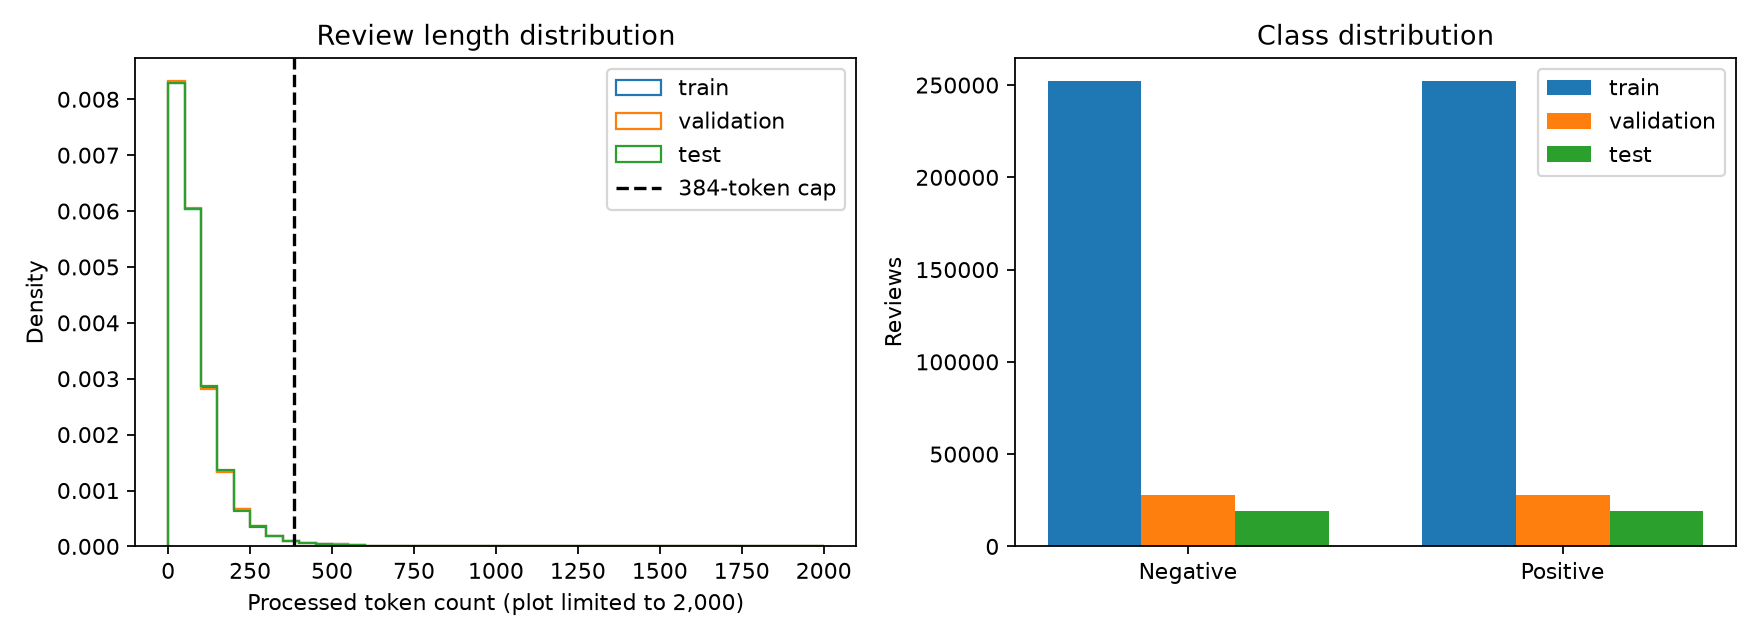

In [2]:
distributions = json.loads((OUTPUTS / "data_distributions.json").read_text())
print(distributions["length_definition"])
display(pd.DataFrame.from_dict(distributions["splits"], orient="index"))
display(Image(filename=str(OUTPUTS / "data_distributions.png"), width=1000))

In [3]:
display(pd.read_csv(OUTPUTS / "model_comparison.csv"))
metrics = pd.read_csv(MEMBER / "metrics_report.csv")
with pd.option_context("display.max_rows", None, "display.max_colwidth", 100):
    display(metrics[["model", "split", "metric", "value"]])

,model,accuracy,macro_f1,roc_auc,mcc,selected_epoch,epochs_run,training_minutes,source_run,embedding_dim,max_length,batch_size,initial_learning_rate,dropout,training_cpu,training_gpu
0,maxpool_mlp,0.932000,0.931999,0.981594,0.864018,5,6,1.617204,runs/part-b-full,128,384,128,0.0015,0.3,AMD EPYC 7543 32-Core Processor,NVIDIA GeForce RTX 5090
1,bilstm,0.960105,0.960103,0.993255,0.920299,10,12,28.105748,runs/part-b-tuning/bilstm_long_schedule_control,128,384,128,0.0010,0.3,AMD EPYC 7543 32-Core Processor,NVIDIA GeForce RTX 5090
2,dilated_cnn,0.958026,0.958026,0.992198,0.916060,6,6,3.811279,runs/part-b-full,128,384,128,0.0008,0.3,AMD EPYC 7543 32-Core Processor,NVIDIA GeForce RTX 5090


,model,split,metric,value
0,maxpool_mlp,test,accuracy,0.932
1,maxpool_mlp,test,confusion_matrix,"[[17770, 1230], [1354, 17646]]"
2,maxpool_mlp,test,roc_auc,0.9815935166204987
3,maxpool_mlp,test,pr_auc_trapezoidal,0.9823367570403351
4,maxpool_mlp,test,mcc,0.8640184006764469
5,maxpool_mlp,test,brier,0.05268637505515327
6,maxpool_mlp,test,ece_15,0.026869014426738343
7,maxpool_mlp,test,test_loss,0.18763503535170303
8,maxpool_mlp,test,macro_precision,0.9320184008723873
9,maxpool_mlp,test,macro_recall,0.9319999999999999


## Timing interpretation

These source runs overlapped other Part B jobs on one RTX 5090. Their measured training times and throughput describe that shared session and are not controlled, isolated architecture-speed comparisons. The initial benchmark is separate evidence in verification/sentiment_5090_benchmark.json.

maxpool_mlp
confusion_matrix.png


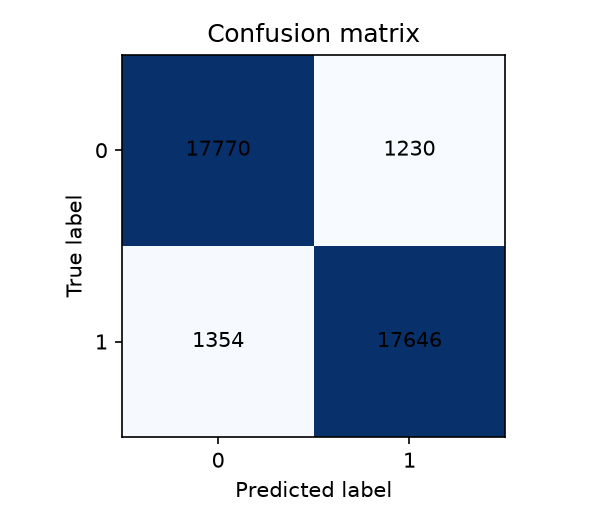

evaluation_curves.png


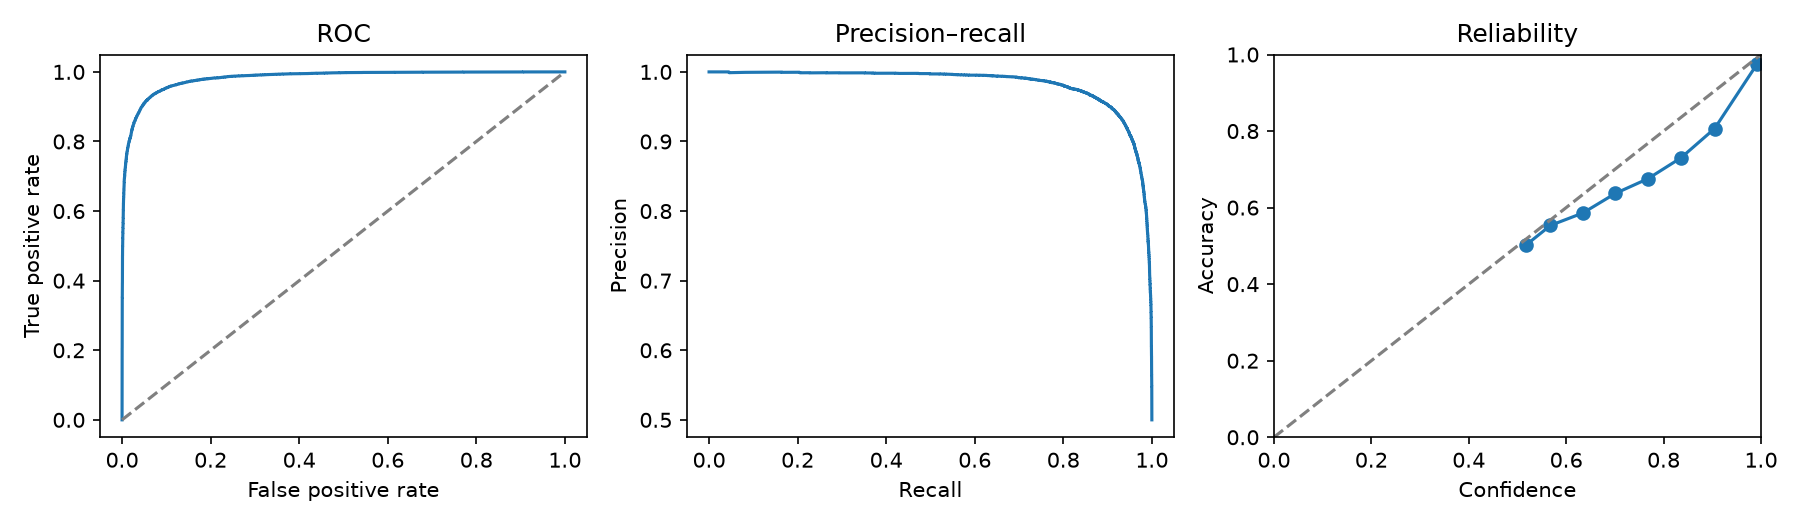

learning_curves.png


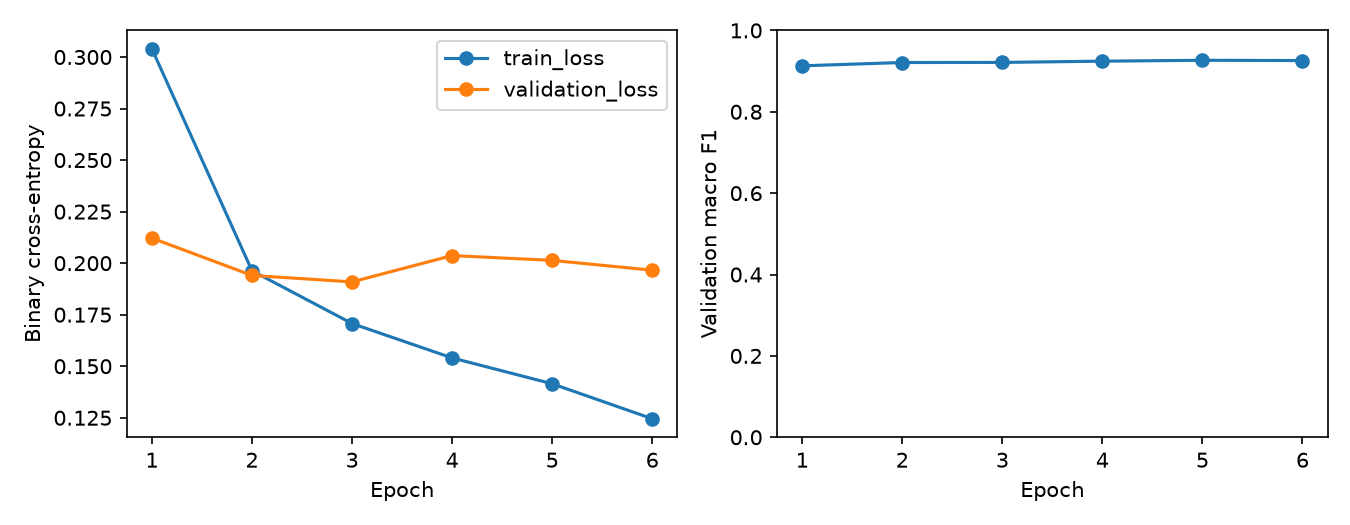

bilstm
confusion_matrix.png


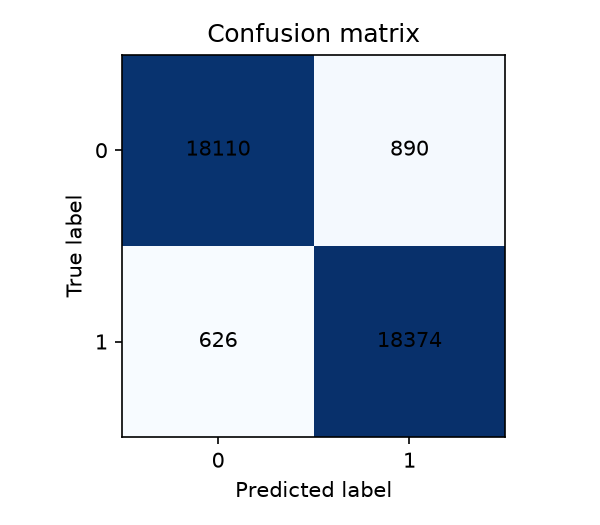

evaluation_curves.png


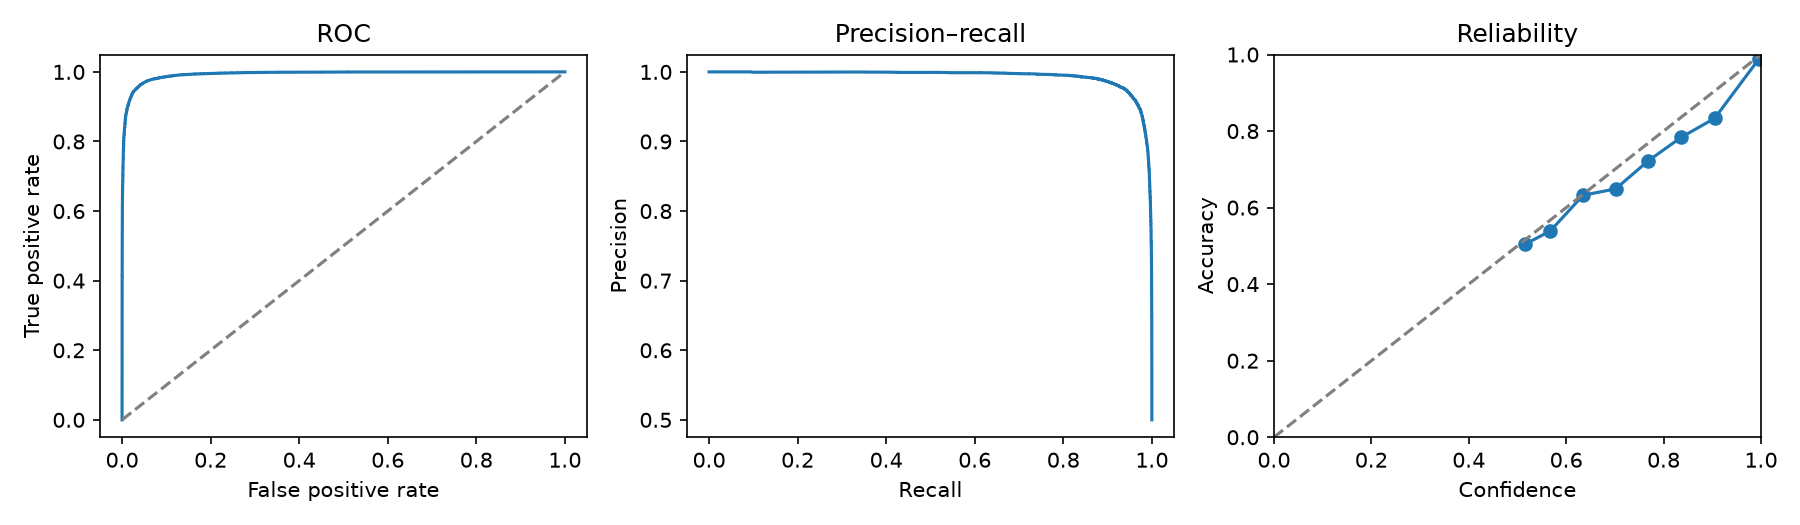

learning_curves.png


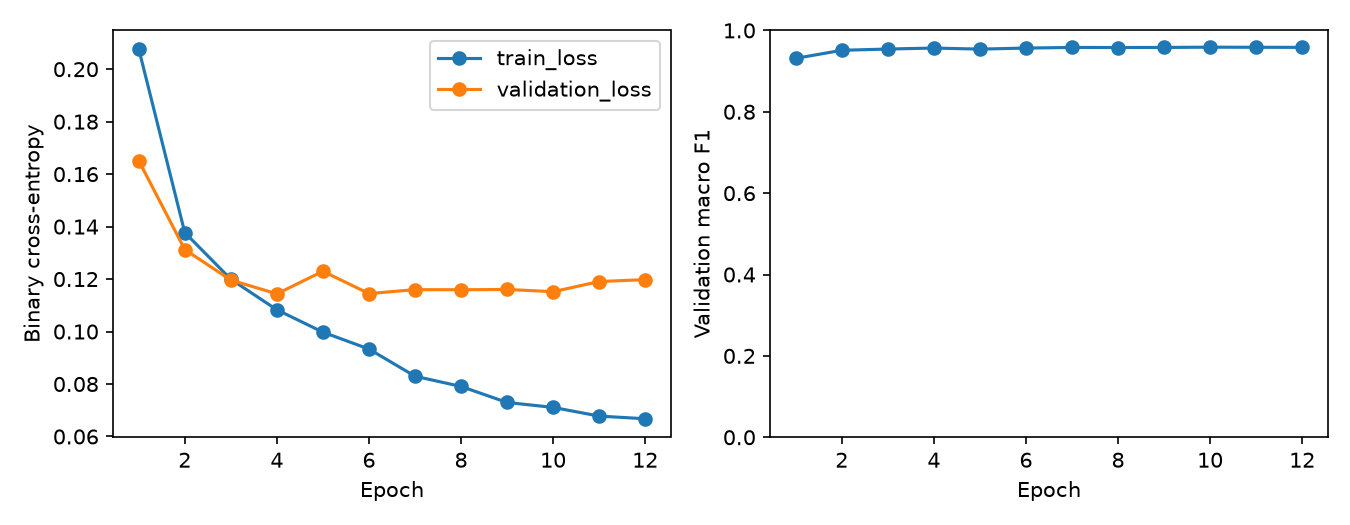

dilated_cnn
confusion_matrix.png


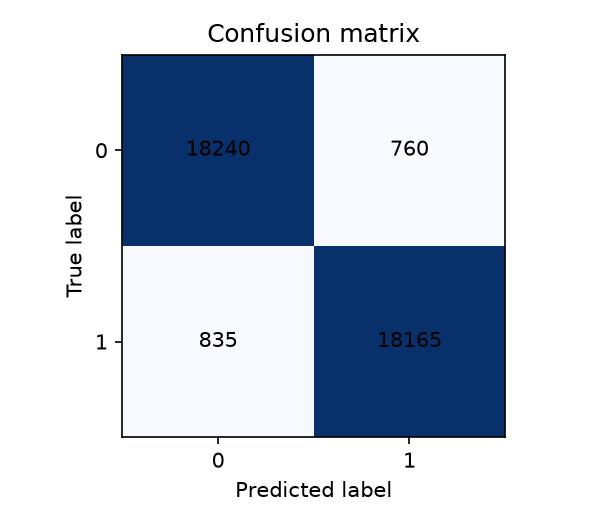

evaluation_curves.png


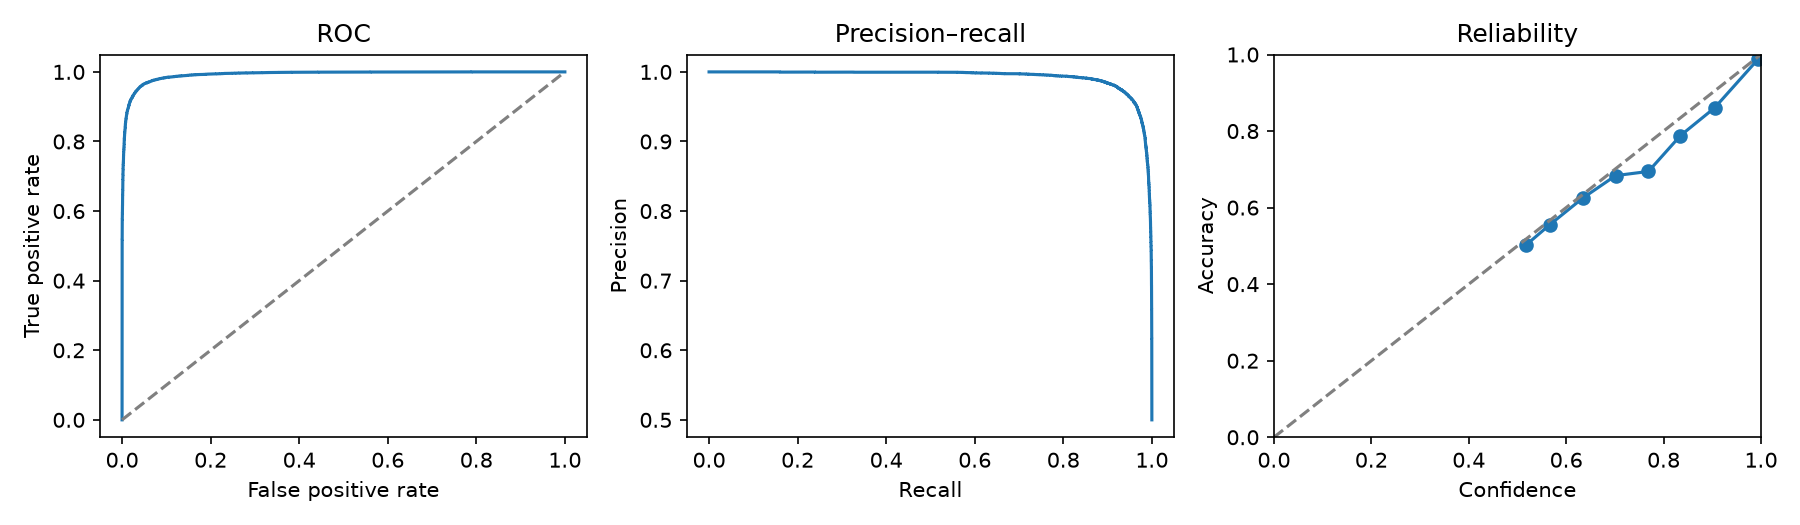

learning_curves.png


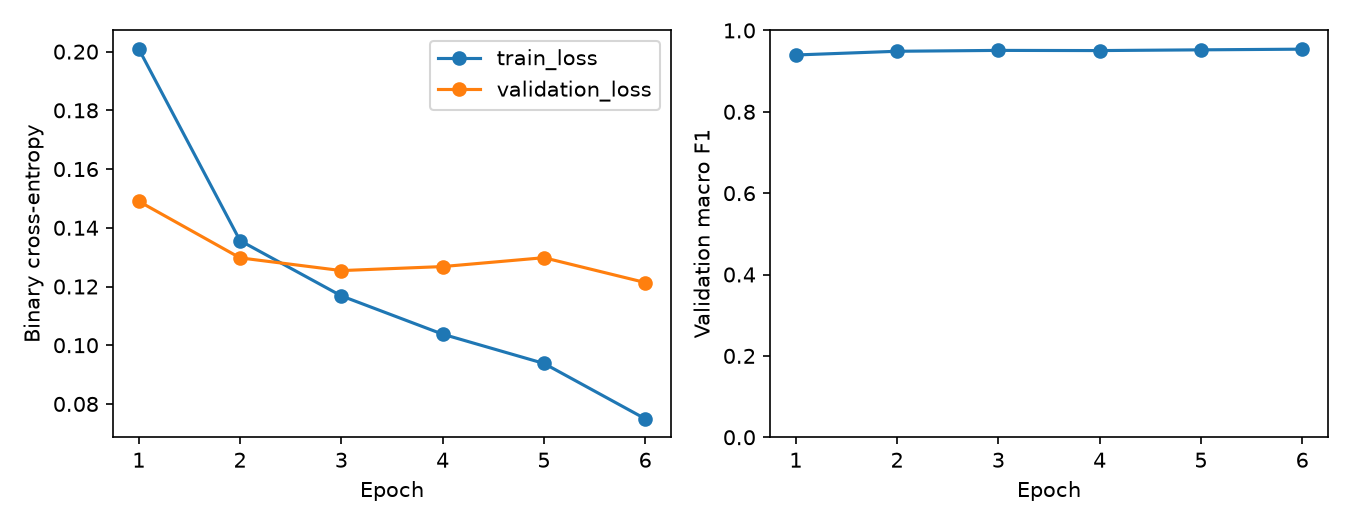

In [4]:
for name in ("maxpool_mlp", "bilstm", "dilated_cnn"):
    print(name)
    for file in sorted((OUTPUTS / name).glob("*.png")):
        print(file.name)
        display(Image(filename=str(file), width=800))

## Required error-review examples

Five confident false positives, five confident false negatives, five near-threshold errors, and five long-review slice failures per model. Error types and testable fixes require student review.

In [5]:
for name in ("maxpool_mlp", "bilstm", "dilated_cnn"):
    print(name)
    display(pd.read_csv(OUTPUTS / name / "required_20_errors_for_review.csv"))

maxpool_mlp


,example_id,true_label,predicted_label,positive_probability,original_token_length,oov_rate,has_negation,text,review_group,error_type,testable_fix,student_reviewed,checkpoint_sha256
0,yelp:test:29330,0,1,0.999993,23,0.000000,False,Wow love the place and everything is very clea...,confident_false_positive,NaN,NaN,False,fc9442519f52db62c292e380fed6285a14e51f2711e754...
1,yelp:test:25701,0,1,0.999920,46,0.000000,True,I had both a red tinga as well as a chili verd...,confident_false_positive,NaN,NaN,False,fc9442519f52db62c292e380fed6285a14e51f2711e754...
2,yelp:test:20681,0,1,0.999870,2,0.000000,False,Large variety,confident_false_positive,NaN,NaN,False,fc9442519f52db62c292e380fed6285a14e51f2711e754...
3,yelp:test:23815,0,1,0.999869,129,0.015504,True,This is the neighborhood Foodland that has the...,confident_false_positive,NaN,NaN,False,fc9442519f52db62c292e380fed6285a14e51f2711e754...
4,yelp:test:12480,0,1,0.999866,13,0.000000,False,my husband had an omelette that was good. i ha...,confident_false_positive,NaN,NaN,False,fc9442519f52db62c292e380fed6285a14e51f2711e754...
5,yelp:test:30958,1,0,0.000051,235,0.000000,True,"Look, we all know Cox sucks. In fact they are ...",confident_false_negative,NaN,NaN,False,fc9442519f52db62c292e380fed6285a14e51f2711e754...
6,yelp:test:22807,1,0,0.000057,60,0.000000,True,EDIT: They really did change the service up si...,confident_false_negative,NaN,NaN,False,fc9442519f52db62c292e380fed6285a14e51f2711e754...
7,yelp:test:30793,1,0,0.000073,64,0.000000,True,This place is so much better since they change...,confident_false_negative,NaN,NaN,False,fc9442519f52db62c292e380fed6285a14e51f2711e754...
8,yelp:test:32713,1,0,0.000101,42,0.000000,True,"Food: Exceptionally nice, a little pricey, bu...",confident_false_negative,NaN,NaN,False,fc9442519f52db62c292e380fed6285a14e51f2711e754...
9,yelp:test:30354,1,0,0.000242,66,0.000000,False,"Maize is good, but the hype has gotten out of ...",confident_false_negative,NaN,NaN,False,fc9442519f52db62c292e380fed6285a14e51f2711e754...


bilstm


,example_id,true_label,predicted_label,positive_probability,original_token_length,oov_rate,has_negation,text,review_group,error_type,testable_fix,student_reviewed,checkpoint_sha256,ai_draft_error_type,ai_draft_reason,ai_draft_testable_fix
0,yelp:test:29330,0,1,0.999996,23,0.000000,False,Wow love the place and everything is very clea...,confident_false_positive,NaN,NaN,False,ed03e33534f053c0b12ceb519c719ea9716c4ece948c20...,Possible text-label disagreement,The supplied negative label conflicts with uni...,"In a future data audit, request independent hu..."
1,yelp:test:22663,0,1,0.999920,117,0.000000,True,About average so far as steakhouses go. My rib...,confident_false_positive,NaN,NaN,False,ed03e33534f053c0b12ceb519c719ea9716c4ece948c20...,Mixed aspects and sarcastic price criticism,"Food and service receive strong praise, but ""m...",Evaluate aspect-aware pooling on validation re...
2,yelp:test:17407,0,1,0.999885,453,0.019868,True,This was my second time dining at Company. And...,confident_false_positive,NaN,NaN,False,ed03e33534f053c0b12ceb519c719ea9716c4ece948c20...,Past-versus-current sentiment and omitted conc...,An enthusiastic account of the first visit pre...,Compare first-384 input with head-and-tail or ...
3,yelp:test:9706,0,1,0.999863,164,0.006098,True,"This hotel was very beautiful, and if you are ...",confident_false_positive,NaN,NaN,False,ed03e33534f053c0b12ceb519c719ea9716c4ece948c20...,Conditional praise and conflicting hotel aspects,The review praises the room and staff but desc...,Build a validation slice of conditional recomm...
4,yelp:test:4655,0,1,0.999860,34,0.000000,False,"good: it's cheap, loud, every now and then a g...",confident_false_positive,NaN,NaN,False,ed03e33534f053c0b12ceb519c719ea9716c4ece948c20...,Mixed pros/cons with possible sarcasm,"The explicit ""good"" list is longer than the ""b...","In a future study, retain punctuation and sent..."
5,yelp:test:22807,1,0,0.000023,60,0.000000,True,EDIT: They really did change the service up si...,confident_false_negative,NaN,NaN,False,ed03e33534f053c0b12ceb519c719ea9716c4ece948c20...,Edit-versus-original text ambiguity,"A short EDIT says the service changed, while t...",Assess edit-aware sentence weighting on valida...
6,yelp:test:10845,1,0,0.000043,13,0.000000,True,I am really pissed they don't have the fresh b...,confident_false_negative,NaN,NaN,False,ed03e33534f053c0b12ceb519c719ea9716c4ece948c20...,Missing-product complaint with ambiguous overa...,The entire short text angrily complains that f...,Create a separate validation slice for complai...
7,yelp:test:15892,1,0,0.000152,96,0.000000,True,"Play here, but don't stay here.\n\nI love the ...",confident_false_negative,NaN,NaN,False,ed03e33534f053c0b12ceb519c719ea9716c4ece948c20...,Opposing gambling and lodging sentiment,"""Play here, but don't stay here"" explicitly se...",Compare sentence- or aspect-level aggregation ...
8,yelp:test:30793,1,0,0.000181,64,0.000000,True,This place is so much better since they change...,confident_false_negative,NaN,NaN,False,ed03e33534f053c0b12ceb519c719ea9716c4ece948c20...,Past-versus-current sentiment reversal,"The old owners are associated with ""terrible"" ...",Use training-derived before/now contrast examp...
9,yelp:test:32999,1,0,0.000382,17,0.000000,True,"I won't say what spilled on my floor carpets, ...",confident_false_negative,NaN,NaN,False,ed03e33534f053c0b12ceb519c719ea9716c4ece948c20...,Literal versus negative lexical sense,"""Their vacuums can REALLY suck"" praises suctio...",Evaluate training-derived contrast pairs for l...


dilated_cnn


,example_id,true_label,predicted_label,positive_probability,original_token_length,oov_rate,has_negation,text,review_group,error_type,testable_fix,student_reviewed,checkpoint_sha256
0,yelp:test:29330,0,1,0.999957,23,0.000000,False,Wow love the place and everything is very clea...,confident_false_positive,NaN,NaN,False,013aa085d21b988169e37951027b280966e5dd550aa776...
1,yelp:test:5752,0,1,0.999888,260,0.011538,True,"NOTE: This was a 4-star review, but the food ...",confident_false_positive,NaN,NaN,False,013aa085d21b988169e37951027b280966e5dd550aa776...
2,yelp:test:17407,0,1,0.999722,453,0.019868,True,This was my second time dining at Company. And...,confident_false_positive,NaN,NaN,False,013aa085d21b988169e37951027b280966e5dd550aa776...
3,yelp:test:4143,0,1,0.999431,84,0.023810,True,**Review only on the Horchatta***\n\nCame here...,confident_false_positive,NaN,NaN,False,013aa085d21b988169e37951027b280966e5dd550aa776...
4,yelp:test:4488,0,1,0.998410,75,0.000000,True,It's good. The rolls are better than the sashi...,confident_false_positive,NaN,NaN,False,013aa085d21b988169e37951027b280966e5dd550aa776...
5,yelp:test:22807,1,0,0.000040,60,0.000000,True,EDIT: They really did change the service up si...,confident_false_negative,NaN,NaN,False,013aa085d21b988169e37951027b280966e5dd550aa776...
6,yelp:test:30793,1,0,0.000156,64,0.000000,True,This place is so much better since they change...,confident_false_negative,NaN,NaN,False,013aa085d21b988169e37951027b280966e5dd550aa776...
7,yelp:test:21215,1,0,0.000199,100,0.000000,True,Last night several parents came in with over 1...,confident_false_negative,NaN,NaN,False,013aa085d21b988169e37951027b280966e5dd550aa776...
8,yelp:test:25329,1,0,0.000217,115,0.008696,True,Im with Kimberly B...this is a card for people...,confident_false_negative,NaN,NaN,False,013aa085d21b988169e37951027b280966e5dd550aa776...
9,yelp:test:29494,1,0,0.000262,202,0.014851,True,UPDATED. \n\nMy initial very frustrated and dr...,confident_false_negative,NaN,NaN,False,013aa085d21b988169e37951027b280966e5dd550aa776...


## Checkpoints and fresh CPU inference

In [6]:
import hashlib
from lab1.sentiment import Reviews, build_model, collate_reviews
torch.set_num_threads(2)
manifest = json.loads((MEMBER / "checkpoints/manifest.json").read_text())
texts = ["The meal was delicious and the staff were friendly.", "The food was cold and the service was terrible."]
for name, files in manifest.items():
    for filename, info in files.items():
        assert hashlib.sha256((ROOT / info["path"]).read_bytes()).hexdigest() == info["sha256"]
    saved = torch.load(ROOT / files["best.pt"]["path"], map_location="cpu", weights_only=False)
    model = build_model(name, len(saved["vocabulary"]), saved["config"]).eval()
    model.load_state_dict(saved["model"], strict=True)
    data = Reviews([{"id": str(i), "text": t, "label": 0} for i,t in enumerate(texts)], saved["vocabulary"], saved["config"]["max_length"])
    ids, _, _ = collate_reviews([data[i] for i in range(len(data))])
    with torch.inference_mode():
        probabilities = torch.sigmoid(model(ids))
    assert torch.isfinite(probabilities).all()
    print(name, "selected epoch", saved["epoch"])
    print(model)
    display(pd.DataFrame({"demo_text": texts, "positive_probability": probabilities.numpy()}))
print("All six checkpoint hashes verified. Demo predictions are separate from test metrics.")

maxpool_mlp selected epoch 5
MaxPoolMLP(
  (embedding): Embedding(40000, 128, padding_idx=0)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


,demo_text,positive_probability
0,The meal was delicious and the staff were frie...,0.999999
1,The food was cold and the service was terrible.,0.000001


bilstm selected epoch 10
BiLSTM(
  (embedding): Embedding(40000, 128, padding_idx=0)
  (embedding_dropout): Dropout(p=0.3, inplace=False)
  (encoder): LSTM(128, 96, batch_first=True, bidirectional=True)
  (head): Sequential(
    (0): Linear(in_features=192, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


,demo_text,positive_probability
0,The meal was delicious and the staff were frie...,0.999761
1,The food was cold and the service was terrible.,0.000069


dilated_cnn selected epoch 6
DilatedCNN(
  (embedding): Embedding(40000, 128, padding_idx=0)
  (projection): Conv1d(128, 128, kernel_size=(1,), stride=(1,))
  (blocks): ModuleList(
    (0): ResidualDilatedBlock(
      (first): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (second): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (1): ResidualDilatedBlock(
      (first): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (second): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (2): ResidualDilatedBlock(
      (first): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (second): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (3): ResidualDilatedBlock(
      (firs

,demo_text,positive_probability
0,The meal was delicious and the staff were frie...,0.999814
1,The food was cold and the service was terrible.,0.000342


All six checkpoint hashes verified. Demo predictions are separate from test metrics.


## Raw log excerpts

The complete unedited log copies are included in outputs/full/raw_logs. Their manifest preserves each original source path and SHA-256. These cells verify the copied bytes and display only the final 12,000 characters.

In [7]:
import hashlib
log_manifest = json.loads((OUTPUTS / "raw_logs/manifest.json").read_text())
for info in log_manifest["logs"]:
    log = OUTPUTS / info["published_path"]
    assert hashlib.sha256(log.read_bytes()).hexdigest() == info["sha256"]
    print(info["role"], info["models"], "original:", info["source_path"])
    print("Published copy:", log.relative_to(ROOT))
    print(log.read_text()[-12000:])

training ['dilated_cnn', 'maxpool_mlp'] original: runs/part-b-full/RUN_LOG.txt
Published copy: task2_sentiment/srinidhi/outputs/full/raw_logs/training_dilated_cnn_maxpool_mlp_8adc9d583f2e_37ce98c3c472.txt
ted_cnn epoch=5/6 batch=3448/3938 step=19200/23628 loss=0.0424 mean_loss=0.0936 elapsed=197.2s eta_steps_est=45.5s
sentiment/dilated_cnn epoch=5/6 batch=3498/3938 step=19250/23628 loss=0.1147 mean_loss=0.0936 elapsed=197.6s eta_steps_est=44.9s
sentiment/dilated_cnn epoch=5/6 batch=3548/3938 step=19300/23628 loss=0.0630 mean_loss=0.0937 elapsed=198.1s eta_steps_est=44.4s
sentiment/dilated_cnn epoch=5/6 batch=3598/3938 step=19350/23628 loss=0.0640 mean_loss=0.0936 elapsed=198.6s eta_steps_est=43.9s
sentiment/dilated_cnn epoch=5/6 batch=3648/3938 step=19400/23628 loss=0.1348 mean_loss=0.0936 elapsed=199.0s eta_steps_est=43.4s
sentiment/dilated_cnn epoch=5/6 batch=3698/3938 step=19450/23628 loss=0.0648 mean_loss=0.0938 elapsed=199.5s eta_steps_est=42.8s
sentiment/dilated_cnn epoch=5/6 bat

## Reproduction commands

Run from the repository root after preparing the documented environment and frozen full-data cache. Each destination below must be new. These commands retrain the selected recipes; preserved source manifests record the original code and environment.

```bash
.venv/bin/python -m lab1.run --task sentiment --mode full --config task2_sentiment/srinidhi/outputs/full/reproduction/maxpool_mlp_full_config.json --device cuda --output runs/reproduce-part2-maxpool_mlp
.venv/bin/python scripts/tune_sentiment.py --candidate task2_sentiment/srinidhi/outputs/full/reproduction/bilstm_candidate.json --output runs/reproduce-part2-bilstm --device cuda
```

To repeat final evaluation of the **preserved selected checkpoints**, use:

```bash
.venv/bin/python scripts/finalize_sentiment_selection.py --selection runs/part-b-selected/selection_manifest.json --output runs/reproduce-part2-final-evaluation
```

After retraining, create a new selection manifest from the new validation results, paths and checkpoint hashes before finalizing those new runs. The command above intentionally references the original frozen selection; it does not select the newly trained runs.

See results.md for metric definitions and limitations. Student error review and teammate comparisons are separate deliverables.